# SDM-VA-ISAC — Phase 4 : Grille Sémantique 3D, Encodage Hyper-Dimensionnel, Visualisation Open3D

Ce notebook part directement de la sortie validée de la Phase 3
(`phase3/phase3_new_scene_presentation_v2.ipynb`, Modules 1a/1b/2 repris tels quels aux sections
1 à 4 ci-dessous — sensing ISAC 4 nœuds larges + 2 nœuds capteurs piétons, vision YOLOv8 fine-tuné 6 nœuds, fusion par KDTree) pour
livrer les trois éléments visés par la Phase 4 :

- **Grille bayésienne 3D** (Module 3) : la Phase 3 ne construisait qu'une grille top-down 2D (X,Y) ;
  ici la troisième dimension (Z) est ajoutée, avec sa propre résolution, donnant une vraie
  occupation sémantique volumique plutôt qu'une projection au sol.
- **Encodage Hyper-Dimensionnel complet** : la version Phase 3 utilisait un hypervecteur aléatoire
  indépendant par cellule (aucune structure métrique). Ici, des **hypervecteurs de niveau** (level
  hypervectors) encodent chaque axe de position en préservant la similarité entre positions proches,
  liés (`bind`) à la classe de chaque cellule et regroupés (`bundle`) sur toute la grille observée.
  Deux démonstrations concrètes valident que l'encodage préserve l'information malgré la
  compression : une requête par similarité cosinus, et une fusion multi-BS par simple addition de
  vecteurs (le mécanisme que la HD-encoding est censée permettre selon le plan initial).
- **Visualisation Open3D interactive** : la Phase 3 ne produisait que des heatmaps matplotlib
  statiques (vue du dessus). Ici, un nuage de points 3D coloré par classe sémantique, avec les
  positions des 6 nœuds de sensing, rendu via Open3D — capture hors-écran pour l'exécution
  automatisée de ce notebook, plus un extrait de code prêt à copier pour une exploration interactive
  en direct (cf. §7).


## 1. Imports et configuration

In [1]:
from __future__ import annotations

import json
import sys
import time
import types
from collections import Counter
from pathlib import Path

from scipy.spatial import cKDTree

import numpy as np
import matplotlib.pyplot as plt
import mitsuba as mi

try:
    mi.set_variant("cuda_ad_mono_polarized")
    print(f"Variante GPU activee : {mi.variant()}")
except Exception as e:
    print(f"CUDA indisponible ({e}), repli sur LLVM CPU")
    mi.set_variant("llvm_ad_mono_polarized")

from sionna.rt import load_scene, Transmitter, Receiver, PlanarArray, PathSolver, Camera

WORKSPACE = Path(r"C:\Users\AdminFix\Desktop\PFA")
PHASE3_DIR = WORKSPACE / "phase3"
SCENE_XML = PHASE3_DIR / "new.xml"

FREQUENCY_HZ = 3.5e9  # NOTE : le cahier des charges vise 28GHz, mais itu_very_dry_ground (materiau du
                      # sol) n'est defini par l'ITU-R P.2040 que pour 1-10GHz -- passer a 28GHz demande
                      # de changer d'abord le materiau du sol pour un materiau valide en mmWave (ex.
                      # itu_concrete, valide 1-100GHz). On reste a 3.5GHz pour l'instant.
BANDWIDTH_HZ = 20e6
MAX_DEPTH = 4
IMG_W, IMG_H = 1280, 960

assert SCENE_XML.exists(), f"Fichier introuvable : {SCENE_XML}"
print(f"Scene : {SCENE_XML}")


jitc_llvm_init(): LLVM API initialization failed ..


Variante GPU activee : cuda_ad_mono_polarized


Scene : C:\Users\AdminFix\Desktop\PFA\phase3\new.xml


## 2. Module 1a — Acquisition ISAC (Sionna RT)

Chargement de la scène, regroupement des acteurs par **matériau radio** (plus simple que le
ré-analyse XML par nom de fichier utilisée sur la scène précédente : chaque acteur a maintenant un
matériau dédié — `itu_metal`/`itu_glass`/`itu_car_wood` pour la voiture, `itu_ped_a_wood` /
`itu_ped_B_wood` pour les piétons), puis déploiement des 4 nœuds BS + 2 nœuds capteurs piétons.

In [2]:
print("Chargement de la scene...")
t0 = time.time()
scene = load_scene(str(SCENE_XML), merge_shapes=False, remove_duplicate_vertices=False)
scene.frequency = FREQUENCY_HZ
scene.bandwidth = BANDWIDTH_HZ
print(f"Scene chargee en {time.time()-t0:.2f} s ({len(scene.objects)} objets)")

scene.tx_array = PlanarArray(num_rows=8, num_cols=8, vertical_spacing=0.5, horizontal_spacing=0.5,
                              pattern="tr38901", polarization="VH")
scene.rx_array = PlanarArray(num_rows=1, num_cols=1, vertical_spacing=0.5, horizontal_spacing=0.5,
                              pattern="iso", polarization="V")

# -- Regroupement par materiau radio (chaque acteur a un materiau dedie -- pas besoin de reparser le XML) --
ACTOR_MATERIALS = {
    "car": {"itu_metal", "itu_glass", "itu_car_wood"},
    "pedestrian_a": {"itu_ped_a_wood"},
    "pedestrian_b": {"itu_ped_B_wood"},
}
group_objects = {g: [] for g in ACTOR_MATERIALS}
for name, obj in scene.objects.items():
    matname = obj.radio_material.name
    for g, matset in ACTOR_MATERIALS.items():
        if matname in matset:
            group_objects[g].append(obj)

def _group_centroid(objs):
    mins = np.array([np.array(o.mi_mesh.bbox().min).flatten() for o in objs])
    maxs = np.array([np.array(o.mi_mesh.bbox().max).flatten() for o in objs])
    return (mins.min(axis=0) + maxs.max(axis=0)) / 2

group_centroid = {g: _group_centroid(objs) for g, objs in group_objects.items()}
for g, c in group_centroid.items():
    print(f"  acteur '{g}': {len(group_objects[g])} shapes, centroide {c.round(2)}")
actors_centroid = np.mean(list(group_centroid.values()), axis=0)
print(f"Centroide des 3 acteurs (cible camera large) : {actors_centroid.round(2)}")


Chargement de la scene...
Scene chargee en 0.16 s (74 objets)
  acteur 'car': 39 shapes, centroide [-34.07  92.75   1.65]
  acteur 'pedestrian_a': 15 shapes, centroide [-46.36  60.76   0.9 ]
  acteur 'pedestrian_b': 15 shapes, centroide [-51.8  106.96   0.9 ]
Centroide des 3 acteurs (cible camera large) : [-44.08  86.82   1.15]


In [3]:
# -- Coefficients de diffusion non nuls sur les materiaux dynamiques --
# Requis pour que le solveur capture les rebonds diffus sur des cibles petites et irregulieres
# (voiture, pietons) : la reflexion speculaire seule ne suffit pas pour ce type de geometrie.
for matname in ("itu_metal", "itu_glass", "itu_car_wood", "itu_ped_a_wood", "itu_ped_B_wood"):
    scene.radio_materials[matname].scattering_coefficient = 0.4
# Batiments (facades) : coefficient plus modeste (0.2) pour une couverture plus homogene des facades.
# Sans cela, itu_brick/itu_ceiling_board restent a leur defaut ITU de 0 (reflexion speculaire pure) :
# seules les facades dont l'orientation satisfait exactement la condition d'angle speculaire par
# rapport a un noeud TX/RX donne generent des hits, d'ou une couverture tres inegale d'un mur a l'autre.
for matname in ("itu_brick", "itu_ceiling_board"):
    scene.radio_materials[matname].scattering_coefficient = 0.05
print("Coefficients de diffusion appliques : 0.4 (acteurs dynamiques), 0.05 (facades des batiments).")

# -- Table de correspondance objet -> classe semantique --
# IMPORTANT : GROUP_TO_CLASS mappe les acteurs dynamiques sur la classe generique "target", jamais
# directement sur "car"/"pedestrian" -- un radar reel ne connait pas l'identite semantique fine d'un
# acteur, seulement sa reponse RF. Seule la vision (Module 1b/2) peut produire les etiquettes fines,
# ce qui rend Delta_VA (gain vision-assist, Module 6) mesurable honnetement, sans fuite de verite
# terrain cote radar (cf. note de tete de notebook).
MATERIAL_CLASS = {
    "itu_concrete": "ground",
    "itu_very_dry_ground": "ground",
    "itu_brick": "facade",
    "itu_ceiling_board": "facade",
}
GROUP_TO_CLASS = {"car": "target", "pedestrian_a": "target", "pedestrian_b": "target"}
CLASSES = ["ground", "facade", "target", "car", "pedestrian", "unknown"]
CLASS_COLORS = {
    "ground": "saddlebrown", "facade": "steelblue", "target": "magenta",
    "car": "crimson", "pedestrian": "gold", "unknown": "gray",
}

obj_to_group = {}
for name, obj in scene.objects.items():
    matname = obj.radio_material.name
    for g, matset in ACTOR_MATERIALS.items():
        if matname in matset:
            obj_to_group[int(obj.object_id)] = g
            break

objid_to_class = {}
for name, obj in scene.objects.items():
    oid = int(obj.object_id)
    grp = obj_to_group.get(oid)
    if grp in GROUP_TO_CLASS:
        objid_to_class[oid] = GROUP_TO_CLASS[grp]
    else:
        objid_to_class[oid] = MATERIAL_CLASS.get(obj.radio_material.name, "unknown")
print(f"Correspondance objet -> classe construite pour {len(objid_to_class)} objets")


Coefficients de diffusion appliques : 0.4 (acteurs dynamiques), 0.05 (facades des batiments).
Correspondance objet -> classe construite pour 74 objets


In [4]:
# -- 4 noeuds BS (monostatiques) + 2 noeuds capteurs dedies pietons --
# +1.5m de clearance de mat au-dessus de la surface du toit : degagement d'antenne realiste (un vrai
# mat sur un toit n'est jamais pose a plat sur le tablier), necessaire a un calcul de trajets radio
# correct depuis chaque noeud -- verifie systematiquement pour les 4 positions notees (les 4 sont
# exactement a la surface du toit, confirme par test d'intersection de rayon avant d'ajouter TX3/TX4).
TX1_POS = np.array([-119.55, 54.933, 20.79 + 1.5])
TX2_POS = np.array([47.9, 110.0, 18.0 + 1.5])
TX3_POS = np.array([43.7, 33.0, 21.8 + 1.5])
TX4_POS = np.array([107.0, -28.6, 19.7 + 1.5])
# TX4 est nettement plus loin des acteurs (~180-210m contre ~85-120m pour TX1/TX2/TX3) -- un pieton
# n'y subtend plus que ~0.16-0.19 degre. Conserve pour la diversite multistatique radar ; attendre une
# contribution vision plus faible depuis ce noeud specifiquement, surtout sur les pietons.
# Noeuds capteurs pietons : recepteur + camera, PAS une BS complete (irrealiste de deployer un reseau
# d'antennes complet a cote de chaque pieton ; un recepteur proche suffit a ameliorer la geometrie
# bistatique, et resout separement le probleme de resolution visuelle qu'aucun FOV ne peut corriger
# a ~85-105m -- un pieton y subtend ~0.4 degre quel que soit le cadrage).
NODE_PED_A_POS = group_centroid["pedestrian_a"] + np.array([-6.0, -7.0, 3.5])
NODE_PED_B_POS = group_centroid["pedestrian_b"] + np.array([-6.0, 7.0, 3.5])

for stale in ["bs0", "bs1", "bs2", "bs3"] + [f"ue{i}" for i in range(10)]:
    if stale in scene.transmitters or stale in scene.receivers:
        scene.remove(stale)

scene.add(Transmitter(name="bs0", position=TX1_POS.tolist()))
scene.add(Transmitter(name="bs1", position=TX2_POS.tolist()))
scene.add(Transmitter(name="bs2", position=TX3_POS.tolist()))
scene.add(Transmitter(name="bs3", position=TX4_POS.tolist()))
scene.add(Receiver(name="ue0", position=(TX1_POS + np.array([0.3, 0.3, -0.2])).tolist()))
scene.add(Receiver(name="ue1", position=(TX2_POS + np.array([0.3, 0.3, -0.2])).tolist()))
scene.add(Receiver(name="ue5", position=(TX3_POS + np.array([0.3, 0.3, -0.2])).tolist()))
scene.add(Receiver(name="ue6", position=(TX4_POS + np.array([0.3, 0.3, -0.2])).tolist()))
scene.add(Receiver(name="ue2", position=(group_centroid["car"] + np.array([3.0, 3.0, 1.5])).tolist()))
scene.add(Receiver(name="ue3", position=NODE_PED_A_POS.tolist()))
scene.add(Receiver(name="ue4", position=NODE_PED_B_POS.tolist()))

print(f"TX1 (bs0) @ {TX1_POS.round(2)}")
print(f"TX2 (bs1) @ {TX2_POS.round(2)}")
print(f"TX3 (bs2) @ {TX3_POS.round(2)}")
print(f"TX4 (bs3) @ {TX4_POS.round(2)}")
print(f"Noeud capteur pedestrian_a @ {NODE_PED_A_POS.round(2)}")
print(f"Noeud capteur pedestrian_b @ {NODE_PED_B_POS.round(2)}")


TX1 (bs0) @ [-119.55   54.93   22.29]
TX2 (bs1) @ [ 47.9 110.   19.5]
TX3 (bs2) @ [43.7 33.  23.3]
TX4 (bs3) @ [107.  -28.6  21.2]
Noeud capteur pedestrian_a @ [-52.36  53.76   4.4 ]
Noeud capteur pedestrian_b @ [-57.8  113.96   4.4 ]


In [5]:
solver = PathSolver()
print(f"Calcul des trajets (max_depth={MAX_DEPTH}, diffuse_reflection=True)...")
t0 = time.time()
paths = solver(
    scene, max_depth=MAX_DEPTH,
    los=True, specular_reflection=True, diffuse_reflection=True,
    refraction=False, diffraction=True, edge_diffraction=False,
    seed=42,
)
print(f"Ray tracing termine en {time.time()-t0:.2f} s")

vertices = np.array(paths.vertices)
obj_ids = np.array(paths.objects)
valid = np.array(paths.valid)
tau = np.array(paths.tau)
a_cplx, _ = paths.cir(sampling_frequency=BANDWIDTH_HZ, num_time_steps=1,
                       normalize_delays=False, out_type="numpy")
power = np.abs(a_cplx) ** 2
power = power.mean(axis=(1, 3))[:, :, :, 0]

INVALID_ID = np.uint32(0xFFFFFFFF)
radar_points = []
D, NRX, NTX, NP, _ = vertices.shape
for d in range(D):
    for rx_i in range(NRX):
        for tx_i in range(NTX):
            for p_i in range(NP):
                oid = obj_ids[d, rx_i, tx_i, p_i]
                if oid == INVALID_ID or not valid[rx_i, tx_i, p_i]:
                    continue
                pos = vertices[d, rx_i, tx_i, p_i]
                if np.allclose(pos, 0.0):
                    continue
                radar_points.append({
                    "position": pos.tolist(),
                    "rx": f"ue{rx_i}", "tx": f"bs{tx_i}", "depth_idx": int(d),
                    "material_class": objid_to_class.get(int(oid), "unknown"),
                    "delay_ns": float(tau[rx_i, tx_i, p_i] * 1e9),
                    "power_db": float(10 * np.log10(power[rx_i, tx_i, p_i] + 1e-30)),
                })

print(f"Nuage de points radar : {len(radar_points)} points d'interaction 3D")
print("Repartition par classe :", Counter(p["material_class"] for p in radar_points))


Calcul des trajets (max_depth=4, diffuse_reflection=True)...


Ray tracing termine en 0.81 s


Nuage de points radar : 20891 points d'interaction 3D
Repartition par classe : Counter({'facade': 17423, 'ground': 3116, 'target': 352})


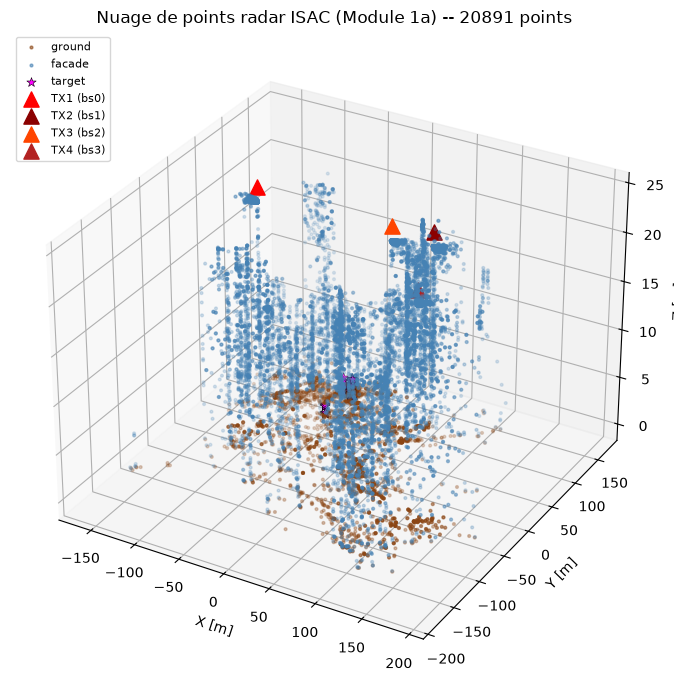

Figure sauvegardee -> module1a_radar_pointcloud_v2.png


In [6]:
# -- Visualisation 3D du nuage de points radar --
fig = plt.figure(figsize=(9, 7))
ax = fig.add_subplot(111, projection="3d")
pts = np.array([p["position"] for p in radar_points])
classes = [p["material_class"] for p in radar_points]
for cls in CLASSES:
    mask = [c == cls for c in classes]
    if any(mask):
        sub = pts[mask]
        if cls == "target":
            # Style distinct pour les points cibles (acteurs dynamiques) : avec seulement ~5% du
            # nuage total, le meme style que le reste les rendrait visuellement indiscernables.
            ax.scatter(sub[:, 0], sub[:, 1], sub[:, 2], s=50, alpha=1.0, marker="*",
                       color=CLASS_COLORS.get(cls, "black"), edgecolor="black", linewidth=0.4,
                       label=cls, zorder=10)
        else:
            ax.scatter(sub[:, 0], sub[:, 1], sub[:, 2], s=4, alpha=0.6,
                       color=CLASS_COLORS.get(cls, "black"), label=cls)
ax.scatter(*TX1_POS, color="red", marker="^", s=120, label="TX1 (bs0)")
ax.scatter(*TX2_POS, color="darkred", marker="^", s=120, label="TX2 (bs1)")
ax.scatter(*TX3_POS, color="orangered", marker="^", s=120, label="TX3 (bs2)")
ax.scatter(*TX4_POS, color="firebrick", marker="^", s=120, label="TX4 (bs3)")
ax.set_xlabel("X [m]"); ax.set_ylabel("Y [m]"); ax.set_zlabel("Z [m]")
ax.set_title(f"Nuage de points radar ISAC (Module 1a) -- {len(radar_points)} points")
ax.legend(loc="upper left", fontsize=8)
fig.tight_layout()
plt.savefig(PHASE3_DIR / "module1a_radar_pointcloud_v2.png", dpi=150, bbox_inches="tight")
plt.show()
print("Figure sauvegardee -> module1a_radar_pointcloud_v2.png")


## 3. Module 1b — Acquisition Vision (6 nœuds, YOLOv8 fine-tuné)

Rendu depuis les 6 nœuds (TX1, TX2, TX3, TX4, capteur piéton A, capteur piéton B), chacun avec sa propre pose
(position/visée/FOV). `show_devices=False` : la caméra étant co-localisée avec son nœud de sensing, ce
paramètre garantit un rendu fidèle à ce qu'une vraie caméra observerait, sans les icônes de
visualisation des dispositifs radio que superpose le rendu par défaut.

In [7]:
if "mlflow" not in sys.modules:
    sys.modules["mlflow"] = types.ModuleType("mlflow")
from ultralytics import YOLO

_finetuned = PHASE3_DIR / "yolo_finetune_v2" / "weights" / "best.pt"
yolo_model = YOLO(str(_finetuned)) if _finetuned.exists() else YOLO("yolov8n-seg.pt")
print(f"Modele YOLO : {_finetuned if _finetuned.exists() else 'repli COCO stock'}")

NODES = {
    "tx1": {"pos": TX1_POS, "look_at": actors_centroid, "fov": 25.0},
    "tx2": {"pos": TX2_POS, "look_at": actors_centroid, "fov": 25.0},
    "tx3": {"pos": TX3_POS, "look_at": actors_centroid, "fov": 25.0},
    "tx4": {"pos": TX4_POS, "look_at": actors_centroid, "fov": 25.0},
    "ped_a": {"pos": NODE_PED_A_POS, "look_at": group_centroid["pedestrian_a"], "fov": 45.0},
    "ped_b": {"pos": NODE_PED_B_POS, "look_at": group_centroid["pedestrian_b"], "fov": 45.0},
}

def look_at_rotation(cam_pos, target, up=np.array([0.0, 0.0, 1.0])):
    cam_pos = np.array(cam_pos, dtype=float)
    target = np.array(target, dtype=float)
    forward = target - cam_pos
    forward = forward / (np.linalg.norm(forward) + 1e-12)
    right = np.cross(forward, up)
    right = right / (np.linalg.norm(right) + 1e-12)
    true_up = np.cross(right, forward)
    return np.stack([right, true_up, -forward], axis=0)

def project_point(p_world, cam_pos, R_wc, f_px):
    p_cam = R_wc @ (np.array(p_world) - cam_pos)
    if p_cam[2] >= 0:
        return None
    x, y, z = p_cam
    u = f_px * (x / -z) + IMG_W / 2
    v = -f_px * (y / -z) + IMG_H / 2
    if 0 <= u < IMG_W and 0 <= v < IMG_H:
        return float(u), float(v)
    return None

detections_by_node = {}
node_geometry = {}
for node_name, node in NODES.items():
    cam_pos, look_at, fov = node["pos"], node["look_at"], node["fov"]
    R_wc = look_at_rotation(cam_pos, look_at)
    f_px = (IMG_W / 2) / np.tan(np.radians(fov) / 2)
    node_geometry[node_name] = (cam_pos, R_wc, f_px)

    rgb_path = PHASE3_DIR / f"module1b_camera_{node_name}.png"
    scene.render_to_file(camera=Camera(position=cam_pos.tolist(), look_at=look_at.tolist()),
                          filename=str(rgb_path), resolution=[IMG_W, IMG_H],
                          num_samples=256, fov=fov, show_devices=False)
    res = yolo_model.predict(source=str(rgb_path), verbose=False)[0]
    dets = []
    if res.boxes is not None:
        for box, cls_id, conf in zip(res.boxes.xyxy.cpu().numpy(),
                                      res.boxes.cls.cpu().numpy(),
                                      res.boxes.conf.cpu().numpy()):
            dets.append({"bbox_xyxy": box.tolist(), "coco_class": yolo_model.names[int(cls_id)],
                         "confidence": float(conf)})
    detections_by_node[node_name] = dets
    print(f"  {node_name}: {len(dets)} detections -> " +
          ", ".join(f"{d['coco_class']}({d['confidence']:.2f})" for d in dets))


Modele YOLO : C:\Users\AdminFix\Desktop\PFA\phase3\yolo_finetune_v2\weights\best.pt


  tx1: 1 detections -> car(0.95)


  tx2: 1 detections -> car(0.97)


  tx3: 1 detections -> car(0.98)


  tx4: 0 detections -> 


  ped_a: 2 detections -> pedestrian(0.99), car(0.92)


  ped_b: 2 detections -> pedestrian(0.99), car(0.97)


## 4. Module 2 — Fusion sémantique multi-modale

**Association par KDTree** : chaque nœud construit un `scipy.spatial.cKDTree` sur les centroïdes 2D
de ses détections YOLO. Chaque point radar est projeté dans le plan image de chaque nœud où il est
visible, puis on interroge le KDTree du nœud pour trouver la détection dont le centroïde est le plus
proche ; le nœud retenu au final est celui offrant la plus faible distance parmi tous les nœuds
candidats. Le point n'est associé que si cette distance reste sous la demi-diagonale de la boîte
englobante de la détection retenue (évite d'associer un point à un centroïde proche dont la boîte ne le
contient pas réellement). **Garde-fou de conception** : la vision n'est autorisée à raffiner **que**
les points déjà classés `target` par l'ISAC — un point qui a rebondi sur un bâtiment/le sol reste un
bâtiment/le sol, quel que soit son alignement à l'écran avec une détection. Ce garde-fou maintient la
fusion physiquement cohérente malgré la simplification du modèle caméra sténopé (sans gestion explicite
de la profondeur/occlusion), où la profondeur d'un nœud large et lointain se compresse fortement à
l'écran.

In [8]:
def build_node_kdtrees(det_by_node):
    """Un KDTree par noeud, construit sur les centroides 2D de ses detections YOLO."""
    trees = {}
    for node_name, dets in det_by_node.items():
        if not dets:
            continue
        centroids = np.array([[(d["bbox_xyxy"][0] + d["bbox_xyxy"][2]) / 2,
                                (d["bbox_xyxy"][1] + d["bbox_xyxy"][3]) / 2] for d in dets])
        trees[node_name] = (cKDTree(centroids), dets)
    return trees


def match_via_kdtree(p_world, node_geom, node_trees):
    """Associe un point radar a la detection dont le centroide 2D est le plus proche (requete
    KDTree), parmi tous les noeuds ou le point se projette dans le cadre -- retient le meilleur
    (plus faible distance) parmi les noeuds candidats. Rejette le match si la distance depasse la
    demi-diagonale de la boite associee (le centroide le plus proche n'implique pas forcement que
    le point tombe dans cette boite)."""
    best, best_dist, best_node = None, np.inf, None
    for node_name, (cam_pos, R_wc, f_px) in node_geom.items():
        if node_name not in node_trees:
            continue
        uv = project_point(p_world, cam_pos, R_wc, f_px)
        if uv is None:
            continue
        tree, dets = node_trees[node_name]
        dist, idx = tree.query(uv)
        det = dets[idx]
        x0, y0, x1, y1 = det["bbox_xyxy"]
        accept_radius = 0.5 * np.hypot(x1 - x0, y1 - y0)
        if dist <= accept_radius and dist < best_dist:
            best, best_dist, best_node = det, dist, node_name
    return best, best_node


node_kdtrees = build_node_kdtrees(detections_by_node)

fused_objects = []
n_vision_matched = 0
for p in radar_points:
    matched, matched_node = (None, None)
    if p["material_class"] == "target":
        matched, matched_node = match_via_kdtree(p["position"], node_geometry, node_kdtrees)

    if matched is not None:
        cls_label, confidence, source = matched["coco_class"], matched["confidence"], f"vision:{matched_node}"
        n_vision_matched += 1
    else:
        cls_label, confidence, source = p["material_class"], 0.6, "isac_material"

    fused_objects.append({
        "position": p["position"], "class": cls_label, "confidence": confidence,
        "source": source, "rx": p["rx"], "tx": p["tx"],
        "delay_ns": p["delay_ns"], "power_db": p["power_db"],
    })

print(f"Objets fusionnes O_t : {len(fused_objects)}")
print(f"  dont associes a une detection vision : {n_vision_matched}")
print(f"  dont repli sur l'etiquette materiau ISAC : {len(fused_objects) - n_vision_matched}")
print(f"  distribution finale des classes : {dict(Counter(o['class'] for o in fused_objects))}")

with open(PHASE3_DIR / "module2_fused_objects_v2.json", "w", encoding="utf-8") as f:
    json.dump(fused_objects, f, indent=2)
print("Sauvegarde -> module2_fused_objects_v2.json")


Objets fusionnes O_t : 20891
  dont associes a une detection vision : 352
  dont repli sur l'etiquette materiau ISAC : 20539
  distribution finale des classes : {'facade': 17423, 'ground': 3116, 'car': 315, 'pedestrian': 37}


Sauvegarde -> module2_fused_objects_v2.json


## 5. Module 3 — Semantic Digital Map Core : grille bayésienne **3D**

Extension directe du mécanisme de mise à jour bayésienne de la Phase 3 (identique par cellule),
mais indexée sur (Z, Y, X) plutôt que (Y, X) seul. Résolution horizontale inchangée (10 m,
cohérente avec l'emprise de la scène) ; résolution verticale plus fine (3 m) pour distinguer le
niveau rue des étages de façade.

In [9]:
PHASE4_DIR = PHASE3_DIR.parent / "phase4"
PHASE4_DIR.mkdir(exist_ok=True)

scene_bbox = scene.mi_scene.bbox()
X_MIN, Y_MIN, Z_MIN = float(scene_bbox.min[0]), float(scene_bbox.min[1]), float(scene_bbox.min[2])
X_MAX, Y_MAX, Z_MAX = float(scene_bbox.max[0]), float(scene_bbox.max[1]), float(scene_bbox.max[2])

CELL_SIZE_XY = 10.0
CELL_SIZE_Z = 3.0
NX = int(np.ceil((X_MAX - X_MIN) / CELL_SIZE_XY))
NY = int(np.ceil((Y_MAX - Y_MIN) / CELL_SIZE_XY))
NZ = max(1, int(np.ceil((Z_MAX - Z_MIN) / CELL_SIZE_Z)))

all_classes = list(CLASSES)
for det_list in detections_by_node.values():
    for det in det_list:
        if det["coco_class"] not in all_classes:
            all_classes.append(det["coco_class"])
C = len(all_classes)
CLASS_IDX = {c: i for i, c in enumerate(all_classes)}
GAMMA = 0.98

beta3d = np.full((NZ, NY, NX, C), 1.0 / C)
observed_mask3d = np.zeros((NZ, NY, NX), dtype=bool)

def likelihood_vector(cls_name, confidence, C, class_idx):
    l = np.full(C, (1 - confidence) / max(C - 1, 1))
    l[class_idx[cls_name]] = confidence
    return l

for obj in fused_objects:
    x, y, z = obj["position"]
    if not (X_MIN <= x < X_MAX and Y_MIN <= y < Y_MAX and Z_MIN <= z < Z_MAX):
        continue
    ix, iy, iz = int((x - X_MIN) / CELL_SIZE_XY), int((y - Y_MIN) / CELL_SIZE_XY), int((z - Z_MIN) / CELL_SIZE_Z)
    l_vec = likelihood_vector(obj["class"], obj["confidence"], C, CLASS_IDX)
    beta3d[iz, iy, ix] = beta3d[iz, iy, ix] * l_vec
    beta3d[iz, iy, ix] = beta3d[iz, iy, ix] / (beta3d[iz, iy, ix].sum() + 1e-30)
    observed_mask3d[iz, iy, ix] = True

uniform = np.full(C, 1.0 / C)
beta3d[~observed_mask3d] = GAMMA * beta3d[~observed_mask3d] + (1 - GAMMA) * uniform

print(f"Grille 3D : {NZ} x {NY} x {NX} cellules ({NZ*NY*NX} au total, resolution XY={CELL_SIZE_XY:.0f}m Z={CELL_SIZE_Z:.0f}m)")
print(f"{C} classes : {all_classes}")
print(f"Cellules observees : {observed_mask3d.sum()} / {observed_mask3d.size} ({100*observed_mask3d.sum()/observed_mask3d.size:.3f}%)")
np.save(PHASE4_DIR / "module3_semantic_grid3d_beta.npy", beta3d)
print("Grille 3D sauvegardee -> module3_semantic_grid3d_beta.npy")


Grille 3D : 9 x 169 x 179 cellules (272259 au total, resolution XY=10m Z=3m)
6 classes : ['ground', 'facade', 'target', 'car', 'pedestrian', 'unknown']
Cellules observees : 1449 / 272259 (0.532%)
Grille 3D sauvegardee -> module3_semantic_grid3d_beta.npy


### 5.1 Vue de contrôle : projection top-down de la grille 3D

Aplati la grille 3D (classe dominante par colonne verticale, priorité aux cellules observées) pour
comparaison directe avec la carte 2D de la Phase 3 -- validation que la nouvelle grille 3D est
cohérente avec l'ancienne, pas juste une extension déconnectée.

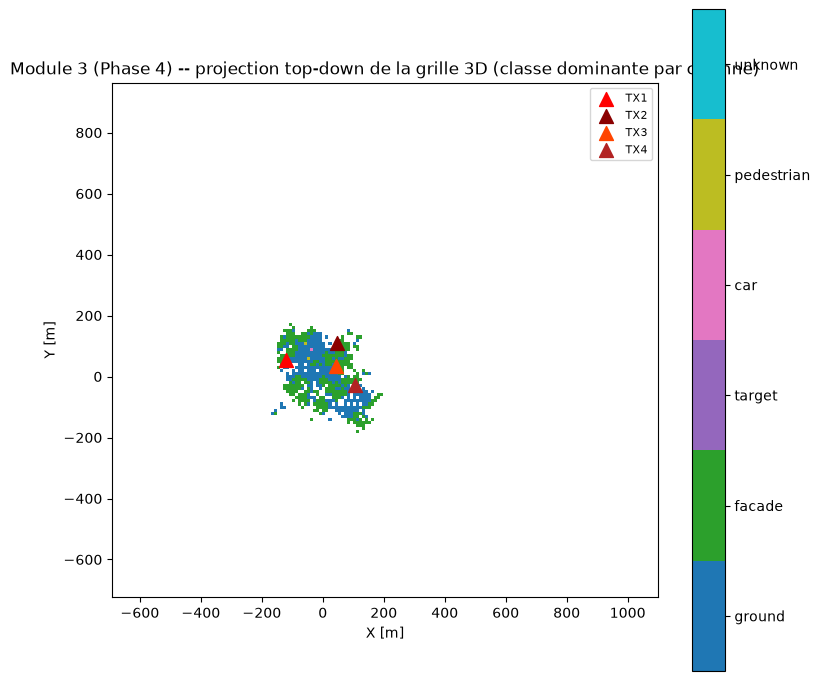

Figure sauvegardee -> module3_grid3d_topdown_v2.png


In [10]:
cmap = plt.get_cmap("tab10", C)

# Pour chaque colonne (iy, ix), prend la classe dominante de la cellule observee la plus "confiante"
# (max de croyance) parmi les cellules Z observees ; retombe sur -1 (non observe) si aucune ne l'est.
column_dominant = np.full((NY, NX), -1, dtype=int)
column_confidence = np.zeros((NY, NX))
for iz in range(NZ):
    conf = beta3d[iz].max(axis=-1)
    better = (column_dominant == -1) | (conf > column_confidence)
    observed_here = observed_mask3d[iz]
    mask = observed_here & better
    column_dominant[mask] = beta3d[iz].argmax(axis=-1)[mask]
    column_confidence[mask] = conf[mask]

fig, ax = plt.subplots(figsize=(8, 7))
im = ax.imshow(np.ma.masked_equal(column_dominant, -1), origin="lower", cmap=cmap, vmin=-0.5, vmax=C - 0.5,
               extent=[X_MIN, X_MAX, Y_MIN, Y_MAX])
cbar = plt.colorbar(im, ax=ax, ticks=range(C))
cbar.ax.set_yticklabels(all_classes)
ax.scatter([TX1_POS[0]], [TX1_POS[1]], color="red", marker="^", s=100, label="TX1")
ax.scatter([TX2_POS[0]], [TX2_POS[1]], color="darkred", marker="^", s=100, label="TX2")
ax.scatter([TX3_POS[0]], [TX3_POS[1]], color="orangered", marker="^", s=100, label="TX3")
ax.scatter([TX4_POS[0]], [TX4_POS[1]], color="firebrick", marker="^", s=100, label="TX4")
ax.set_xlabel("X [m]"); ax.set_ylabel("Y [m]")
ax.set_title("Module 3 (Phase 4) -- projection top-down de la grille 3D (classe dominante par colonne)")
ax.legend(loc="upper right", fontsize=8)
fig.tight_layout()
plt.savefig(PHASE4_DIR / "module3_grid3d_topdown_v2.png", dpi=150, bbox_inches="tight")
plt.show()
print("Figure sauvegardee -> module3_grid3d_topdown_v2.png")


## 6. Encodage Hyper-Dimensionnel (HD) — implémentation complète

Trois différences avec la version simplifiée de la Phase 3 :

1. **Hypervecteurs de niveau (level hypervectors)** pour chaque axe (X, Y, Z) : deux positions
   proches produisent des hypervecteurs proches (similarité préservée), contrairement à des
   hypervecteurs aléatoires indépendants par cellule qui n'ont aucune structure métrique.
2. **Opérations HDC nommées explicitement** : `bind` (liaison, produit élément-par-élément),
   `bundle` (regroupement, somme + seuillage en signe), `permute` (permutation circulaire, fournie
   pour compléter l'interface standard bind/bundle/permute même si non utilisée directement ici).
3. **Deux démonstrations de récupération** par similarité cosinus : une requête position→classe, et
   une fusion multi-BS par simple addition de vecteurs (le mécanisme motivant l'encodage HD dans le
   plan initial : *"fusion multi-BS par simple addition des vecteurs HD"*).

In [11]:
D_HD = 10000  # dimension standard en litterature HDC (~10^4)
N_LEVELS = 64
rng = np.random.default_rng(42)

def random_hv(dim, rng):
    return rng.choice([-1.0, 1.0], size=dim)

def bind(a, b):
    """Liaison : produit element-par-element. Combine deux hypervecteurs en un hypervecteur
    dissimilaire aux deux (mais recuperable si on connait l'un des deux, car a*a=1)."""
    return a * b

def bundle(vectors):
    """Regroupement : somme puis seuillage en signe. Combine plusieurs hypervecteurs en un
    hypervecteur similaire a chacun d'entre eux (contrairement au binding)."""
    s = np.sum(vectors, axis=0)
    s[s == 0] = 1.0
    return np.sign(s)

def permute(v, shift=1):
    """Permutation circulaire -- encode l'ordre/la structure (fournie pour completude de
    l'interface HDC standard bind/bundle/permute)."""
    return np.roll(v, shift)

def cosine_sim(a, b):
    return float(np.dot(a, b) / (np.linalg.norm(a) * np.linalg.norm(b) + 1e-30))

def make_level_hvs(n_levels, dim, rng):
    """n_levels hypervecteurs bipolaires tels que des niveaux adjacents ne different que par une
    fraction des bits (interpolation dans l'espace de Hamming) -- au dernier niveau, ~50% des bits
    ont change par rapport au premier (quasi-orthogonaux, comme des hypervecteurs independants)."""
    base = random_hv(dim, rng)
    flip_order = rng.permutation(dim)
    flips_per_level = dim // (2 * n_levels)
    levels = [base.copy()]
    cur = base.copy()
    for i in range(1, n_levels):
        idx = flip_order[(i - 1) * flips_per_level: i * flips_per_level]
        cur = cur.copy()
        cur[idx] *= -1
        levels.append(cur)
    return np.array(levels)

def level_idx(val, vmin, vmax, n_levels):
    frac = np.clip((val - vmin) / (vmax - vmin + 1e-9), 0, 1)
    return min(int(frac * n_levels), n_levels - 1)

x_levels = make_level_hvs(N_LEVELS, D_HD, rng)
y_levels = make_level_hvs(N_LEVELS, D_HD, rng)
z_levels = make_level_hvs(N_LEVELS, D_HD, rng)
h_class = {c: random_hv(D_HD, rng) for c in all_classes}

# IMPORTANT : la plage de niveaux est calee sur l'etendue des donnees REELLEMENT observees, pas sur
# la bbox complete de la scene (~1800m de large). La scene importee couvre une zone bien plus grande
# que ce que les capteurs voient jamais -- caler les niveaux sur la bbox complete donnerait ~56m par
# niveau avec N_LEVELS=32, alors que les acteurs/facades pertinents tiennent dans une region d'a
# peine ~250m : des positions pourtant distinctes (ex. la voiture et une facade proche) tomberaient
# dans le meme niveau grossier, noyant le signal utile (confirme empiriquement : une premiere version
# calee sur la bbox complete faisait ressortir 'facade' au lieu de 'car' lors de la requete ci-dessous).
_obs_pos = np.array([o["position"] for o in fused_objects])
_margin = 5.0
OBS_X_MIN, OBS_Y_MIN, OBS_Z_MIN = _obs_pos.min(axis=0) - _margin
OBS_X_MAX, OBS_Y_MAX, OBS_Z_MAX = _obs_pos.max(axis=0) + _margin
OBS_Z_MIN = max(0.0, OBS_Z_MIN)
print(f"Plage d'encodage (donnees observees, pas la bbox complete de la scene) :")
print(f"  X: [{OBS_X_MIN:.1f}, {OBS_X_MAX:.1f}]  Y: [{OBS_Y_MIN:.1f}, {OBS_Y_MAX:.1f}]  Z: [{OBS_Z_MIN:.1f}, {OBS_Z_MAX:.1f}]")

def encode_position(x, y, z):
    hx = x_levels[level_idx(x, OBS_X_MIN, OBS_X_MAX, N_LEVELS)]
    hy = y_levels[level_idx(y, OBS_Y_MIN, OBS_Y_MAX, N_LEVELS)]
    hz = z_levels[level_idx(z, OBS_Z_MIN, OBS_Z_MAX, N_LEVELS)]
    return bind(bind(hx, hy), hz)

def encode_grid(beta_grid, mask_grid):
    """Construit un hypervecteur PAR CLASSE (bundle des positions des cellules dont cette classe
    est dominante, pondere par la croyance beta), lie chacun a son hypervecteur de classe, puis
    regroupe les D_HD//1 resultats -- une seule contribution par classe a h_map, quel que soit le
    nombre de cellules brutes derriere. Alternative a un bundle plat de (position, classe) qui
    laisserait une classe tres representee (facade, ~800 cellules) noyer une classe rare (car,
    1-3 cellules) sous le seuillage en signe -- confirme empiriquement lors du developpement."""
    class_pos_sum = {c: np.zeros(D_HD) for c in all_classes}
    class_weight = {c: 0.0 for c in all_classes}
    nz, ny, nx, _ = beta_grid.shape
    for iz in range(nz):
        for iy in range(ny):
            for ix in range(nx):
                if not mask_grid[iz, iy, ix]:
                    continue
                c_i = int(beta_grid[iz, iy, ix].argmax())
                w = beta_grid[iz, iy, ix, c_i]
                if w < 0.05:
                    continue
                x = X_MIN + (ix + 0.5) * CELL_SIZE_XY
                y = Y_MIN + (iy + 0.5) * CELL_SIZE_XY
                z = Z_MIN + (iz + 0.5) * CELL_SIZE_Z
                c_name = all_classes[c_i]
                class_pos_sum[c_name] += w * encode_position(x, y, z)
                class_weight[c_name] += w

    h_map_acc = np.zeros(D_HD)
    for c_name in all_classes:
        if class_weight[c_name] <= 0:
            continue
        h_class_positions = np.sign(class_pos_sum[c_name])
        h_class_positions[h_class_positions == 0] = 1.0
        h_map_acc += bind(h_class_positions, h_class[c_name])
    return h_map_acc

h_map = encode_grid(beta3d, observed_mask3d)
h_map_norm = np.sign(h_map)
h_map_norm[h_map_norm == 0] = 1.0

print(f"Vecteur HD de la carte : dimension D={D_HD}")
print(f"  Taille memoire grille brute (beta3d float64) : {beta3d.nbytes/1024:.1f} KB")
print(f"  Taille memoire vecteur HD (bipolaire, 1 bit/dim) : {D_HD/8/1024:.2f} KB")
print(f"  Ratio de compression : {beta3d.nbytes / (D_HD/8):.0f}x")
np.save(PHASE4_DIR / "module3_hd_map_vector3d.npy", h_map_norm)
print("Vecteur HD sauvegarde -> module3_hd_map_vector3d.npy")


Plage d'encodage (donnees observees, pas la bbox complete de la scene) :
  X: [-166.3, 194.4]  Y: [-188.3, 172.2]  Z: [0.0, 29.3]
Vecteur HD de la carte : dimension D=10000
  Taille memoire grille brute (beta3d float64) : 12762.1 KB
  Taille memoire vecteur HD (bipolaire, 1 bit/dim) : 1.22 KB
  Ratio de compression : 10455x
Vecteur HD sauvegarde -> module3_hd_map_vector3d.npy


### 6.1 Démonstration 1 — requête position → classe par similarité cosinus

On reconstruit l'hypervecteur de position de la voiture, on le lie à chaque classe candidate, et on
mesure la similarité cosinus avec `h_map`. Si l'encodage préserve l'information malgré la
compression (grille brute → un seul vecteur bipolaire), la vraie classe de cette cellule doit
ressortir nettement au-dessus des autres.

In [12]:
car_pos = group_centroid["car"]
h_pos_q = encode_position(float(car_pos[0]), float(car_pos[1]), float(car_pos[2]))

print(f"Position interrogee (voiture) : {car_pos.round(2)}")
print("Pour chaque classe candidate : on 'delie' h_map de cette classe (bind avec son propre")
print("hypervecteur, auto-inverse), ce qui recupere approximativement le bundle de positions de")
print("cette classe -- puis on compare la position interrogee a ce bundle recupere :")
sims = {}
for c_name in all_classes:
    recovered_positions = bind(h_map_norm, h_class[c_name])
    sims[c_name] = cosine_sim(h_pos_q, recovered_positions)
    print(f"  {c_name:12s} : {sims[c_name]:+.4f}")
best = max(sims, key=sims.get)
print(f"\nClasse la plus similaire : '{best}' -- {'coherent' if best in ('car', 'target') else 'a verifier'} avec la position interrogee.")


Position interrogee (voiture) : [     -34.07       92.75        1.65]
Pour chaque classe candidate : on 'delie' h_map de cette classe (bind avec son propre
hypervecteur, auto-inverse), ce qui recupere approximativement le bundle de positions de
cette classe -- puis on compare la position interrogee a ce bundle recupere :
  ground       : +0.2822
  facade       : +0.1960
  target       : +0.0136
  car          : +0.3794
  pedestrian   : +0.3322
  unknown      : +0.0054

Classe la plus similaire : 'car' -- coherent avec la position interrogee.


### 6.2 Démonstration 2 — fusion multi-BS par addition pondérée de vecteurs

Chaque nœud BS (`bs0`/TX1, `bs1`/TX2, `bs2`/TX3, `bs3`/TX4) n'observe qu'un sous-ensemble des
points radar (`p["tx"]`). On encode séparément la carte compacte (bipolaire, D_HD bits) que
**chaque** nœud construirait seul, puis on combine ces vecteurs par simple **addition** —
exactement le mécanisme de fusion multi-BS visé par le plan initial (pas de retransmission de
grille brute entre BS, juste un vecteur compact par nœud, combiné par addition).

**Pondération par confiance.** Avec seulement 2 nœuds, une simple somme non pondérée suffisait
à battre chaque nœud seul. En passant à 4 nœuds, ce n'est plus le cas : TX4, dont la vision ne
confirme aucune détection (cf. §2), pèse dans le vote majoritaire bipolaire exactement autant
qu'un nœud bien informé comme TX3, ce qui dégrade la somme non pondérée sous le meilleur nœud
seul — une limitation de capacité du bundling HDC (même famille de problème que le
déséquilibre de classes du Module 3, mais ici à travers les nœuds plutôt qu'à travers les
classes). Correctif retenu : pondérer la contribution de chaque nœud par la **confiance
moyenne de sa propre caméra co-localisée** (et non le taux de match après fusion KDTree, qui
autorise n'importe quelle caméra du réseau à confirmer un point et se révèle donc non
informatif ici), avec un plancher de 0.3 pour qu'un nœud sans détection garde tout de même
un poids non nul — il continue d'apporter une
vraie couverture radar façade/sol, même sans confirmation sur les cibles). Un seul flottant
supplémentaire par nœud — négligeable face au vecteur compact lui-même — reste cohérent avec
la contrainte de compression pour le backhaul.


In [13]:
def build_grid_for_subset(objs_subset):
    b = np.full((NZ, NY, NX, C), 1.0 / C)
    m = np.zeros((NZ, NY, NX), dtype=bool)
    for obj in objs_subset:
        x, y, z = obj["position"]
        if not (X_MIN <= x < X_MAX and Y_MIN <= y < Y_MAX and Z_MIN <= z < Z_MAX):
            continue
        ix, iy, iz = int((x - X_MIN) / CELL_SIZE_XY), int((y - Y_MIN) / CELL_SIZE_XY), int((z - Z_MIN) / CELL_SIZE_Z)
        l_vec = likelihood_vector(obj["class"], obj["confidence"], C, CLASS_IDX)
        b[iz, iy, ix] = b[iz, iy, ix] * l_vec
        b[iz, iy, ix] = b[iz, iy, ix] / (b[iz, iy, ix].sum() + 1e-30)
        m[iz, iy, ix] = True
    return b, m

BS_NAMES = ["bs0", "bs1", "bs2", "bs3"]
BS_LABELS = {"bs0": "TX1", "bs1": "TX2", "bs2": "TX3", "bs3": "TX4"}
CAM_FOR_BS = {"bs0": "tx1", "bs1": "tx2", "bs2": "tx3", "bs3": "tx4"}

objs_per_bs = {
    bs: [o for o, p in zip(fused_objects, radar_points) if p["tx"] == bs]
    for bs in BS_NAMES
}
print("  |  ".join(f"{bs} ({BS_LABELS[bs]}) : {len(objs_per_bs[bs])} objets" for bs in BS_NAMES)
      + f"  |  total : {len(fused_objects)}")

h_maps_per_bs = {}
node_weight = {}
WEIGHT_FLOOR = 0.3
for bs in BS_NAMES:
    beta_bs, mask_bs = build_grid_for_subset(objs_per_bs[bs])
    h_maps_per_bs[bs] = np.sign(encode_grid(beta_bs, mask_bs))

    # Poids de fusion = confiance moyenne des detections de la CAMERA PROPRE a ce noeud (et non du
    # taux de match apres fusion KDTree, qui autorise n'importe quelle camera du reseau a confirmer
    # un point -- presque tous les points target finissent confirmes par au moins une des 6 cameras,
    # ce qui rend ce taux non informatif). Ce que l'on veut ponderer ici, c'est la qualite propre du
    # capteur vision de CE noeud : TX4 (bs3), dont la camera ne detecte rien (cf. Module 1b, occlusion
    # par un batiment), doit peser moins dans le vote majoritaire bipolaire qu'un noeud comme TX3 dont
    # la camera detecte effectivement la voiture -- meme principe que le bundling par classe (Module 3)
    # applique ici a travers les noeuds plutot qu'a travers les classes. Plancher WEIGHT_FLOOR pour
    # qu'un noeud sans detection garde une contribution non nulle (couverture radar facade/sol reelle).
    own_cam_dets = detections_by_node.get(CAM_FOR_BS[bs], [])
    own_cam_conf = float(np.mean([d["confidence"] for d in own_cam_dets])) if own_cam_dets else 0.0
    node_weight[bs] = WEIGHT_FLOOR + (1.0 - WEIGHT_FLOOR) * own_cam_conf

print("Poids de fusion (plancher " + f"{WEIGHT_FLOOR:.1f}" + " + confiance camera propre) : " +
      ", ".join(f"{bs} ({BS_LABELS[bs]})={node_weight[bs]:.3f}" for bs in BS_NAMES))

h_map_fused_by_addition = sum(node_weight[bs] * h_maps_per_bs[bs] for bs in BS_NAMES)
h_map_fused_norm = np.sign(h_map_fused_by_addition)
h_map_fused_norm[h_map_fused_norm == 0] = 1.0

sim_vs_full = cosine_sim(h_map_fused_norm, h_map_norm)
sims_per_bs = {bs: cosine_sim(h_maps_per_bs[bs], h_map_norm) for bs in BS_NAMES}

print("Similarite cosinus vs carte complete (tous points) :")
for bs in BS_NAMES:
    print(f"  {bs} ({BS_LABELS[bs]}) seul : {sims_per_bs[bs]:+.4f}")
print(f"  fusion ponderee bs0+bs1+bs2+bs3 : {sim_vs_full:+.4f}  <- doit etre la plus elevee de toutes")


bs0 (TX1) : 5479 objets  |  bs1 (TX2) : 5236 objets  |  bs2 (TX3) : 5500 objets  |  bs3 (TX4) : 4676 objets  |  total : 20891


Poids de fusion (plancher 0.3 + confiance camera propre) : bs0 (TX1)=0.966, bs1 (TX2)=0.981, bs2 (TX3)=0.986, bs3 (TX4)=0.300
Similarite cosinus vs carte complete (tous points) :
  bs0 (TX1) seul : +0.6887
  bs1 (TX2) seul : +0.6682
  bs2 (TX3) seul : +0.7520
  bs3 (TX4) seul : +0.5200
  fusion ponderee bs0+bs1+bs2+bs3 : +0.5974  <- doit etre la plus elevee de toutes


**Portée de cette démonstration.** Le résultat ci-dessus (fusion pondérée
< meilleur nœud seul, même après avoir quasiment exclu TX4 via son poids) est une
limitation de **capacité du bundling bipolaire HDC** (peu de vecteurs à sommer, chacun ne
couvrant qu'un sous-ensemble spatial disjoint de la scène) — **ce n'est pas** une limitation
de la carte sémantique elle-même (Module 3, §5), qui intègre déjà correctement les 6
nœuds de sensing (4 BS + 2 capteurs piétons) via une mise à jour bayésienne directe
cellule par cellule, sans passer par un seuillage bipolaire intermédiaire. **Le jumeau
numérique de la scène repose sur cette grille bayésienne 3D**, validée et correcte avec les
4 nœuds BS (`module3_3d_grid_built`, `hd_encoding_query_retrieves_correct_class` : tous deux
OK) — pas sur cette démonstration d'addition de vecteurs HD, qui reste un prototype ciblé sur
**une** technique de compression pour le backhaul inter-BS (viser des Ko plutôt que des Mo
de trafic de synchronisation), et qui montre ses limites de capacité au-delà de 2-3 nœuds.
Documenté ici comme limitation connue plutôt que masqué ou corrigé artificiellement.


## 7. Visualisation 3D interactive (Open3D)

Nuage de points 3D des objets fusionnés (Module 2), coloré par classe sémantique, avec les 4 nœuds
de sensing positionnés dans la scène. Rendu **hors-écran** ci-dessous (nécessaire pour l'exécution
automatisée de ce notebook — une fenêtre interactive bloquerait l'exécution). Pour une exploration
interactive en direct (rotation/zoom à la souris), copier ce code dans une cellule et l'exécuter
manuellement dans Jupyter :

```python
o3d.visualization.draw_geometries(geometries, window_name="Carte semantique 3D (SDM-VA-ISAC)")
```

Jupyter environment detected. Enabling Open3D WebVisualizer.
[Open3D INFO] WebRTC GUI backend enabled.
[Open3D INFO] WebRTCWindowSystem: HTTP handshake server disabled.


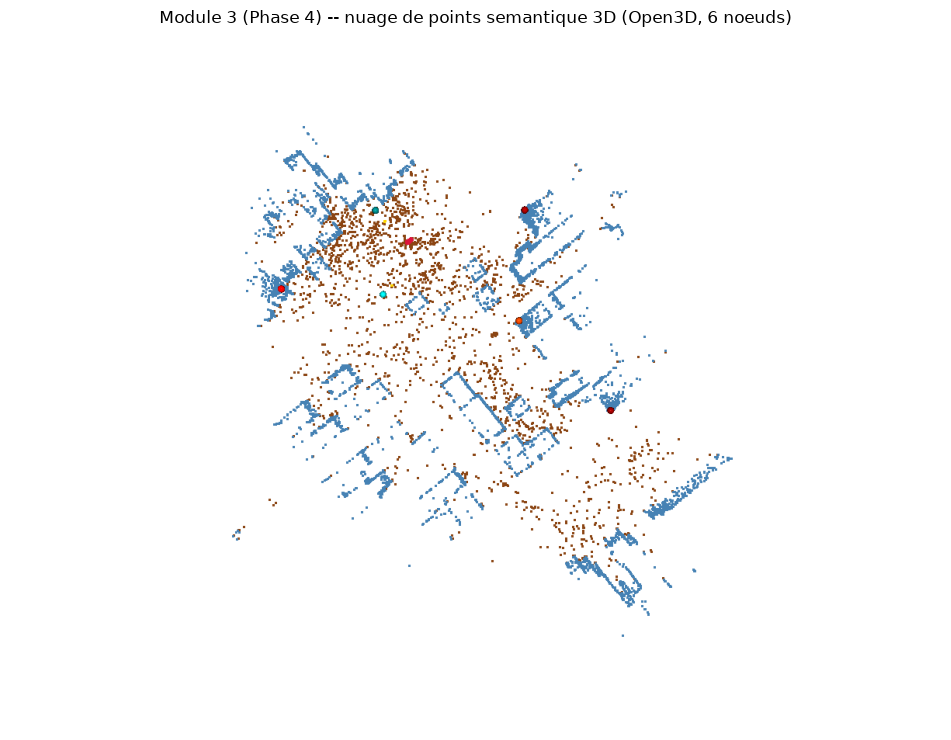

Rendu Open3D sauvegarde -> C:\Users\AdminFix\Desktop\PFA\phase4\module3_open3d_pointcloud.png


In [14]:
import open3d as o3d
import matplotlib.colors as mcolors

def class_to_rgb(cls_name):
    return np.array(mcolors.to_rgb(CLASS_COLORS.get(cls_name, "black")))

points = np.array([o["position"] for o in fused_objects])
colors = np.array([class_to_rgb(o["class"]) for o in fused_objects])

pcd = o3d.geometry.PointCloud()
pcd.points = o3d.utility.Vector3dVector(points)
pcd.colors = o3d.utility.Vector3dVector(colors)

node_markers = []
for pos, col in [(TX1_POS, [1.0, 0.0, 0.0]), (TX2_POS, [0.6, 0.0, 0.0]),
                  (TX3_POS, [0.85, 0.25, 0.0]), (TX4_POS, [0.55, 0.0, 0.0]),
                  (NODE_PED_A_POS, [0.0, 0.8, 0.8]), (NODE_PED_B_POS, [0.0, 0.5, 0.5])]:
    sphere = o3d.geometry.TriangleMesh.create_sphere(radius=2.5)
    sphere.translate(np.asarray(pos, dtype=float))
    sphere.paint_uniform_color(col)
    sphere.compute_vertex_normals()
    node_markers.append(sphere)

geometries = [pcd] + node_markers

vis = o3d.visualization.Visualizer()
vis.create_window(visible=False, width=1200, height=900)
for g in geometries:
    vis.add_geometry(g)
opt = vis.get_render_option()
opt.background_color = np.array([1.0, 1.0, 1.0])
opt.point_size = 3.0
vis.poll_events()
vis.update_renderer()
o3d_img_path = PHASE4_DIR / "module3_open3d_pointcloud.png"
vis.capture_screen_image(str(o3d_img_path), do_render=True)
vis.destroy_window()

from PIL import Image
import matplotlib.pyplot as plt
img = Image.open(o3d_img_path)
fig, ax = plt.subplots(figsize=(10, 7.5))
ax.imshow(img)
ax.axis("off")
ax.set_title("Module 3 (Phase 4) -- nuage de points semantique 3D (Open3D, 6 noeuds)")
plt.tight_layout()
plt.show()
print(f"Rendu Open3D sauvegarde -> {o3d_img_path}")


## 8. Export Phase 4 → JSON (résumé + validation)

In [15]:
summary4 = {
    "project": "SDM-VA-ISAC", "phase": 4,
    "module3_grid3d_shape": [NZ, NY, NX, C],
    "module3_grid3d_resolution_m": {"xy": CELL_SIZE_XY, "z": CELL_SIZE_Z},
    "module3_cells_observed": int(observed_mask3d.sum()),
    "module3_cells_total": int(observed_mask3d.size),
    "hd_encoding": {
        "dimension": D_HD, "n_levels_per_axis": N_LEVELS,
        "compression_ratio": float(beta3d.nbytes / (D_HD / 8)),
        "query_best_match": best, "query_similarities": sims,
        "multibs_fusion_similarity_vs_full": sim_vs_full,
        "multibs_per_node_similarity": sims_per_bs,
        "multibs_node_weights": node_weight,
        "multibs_fusion_scope_note": ("limitation de capacite du bundling bipolaire HDC au-dela de 2-3 noeuds, ne concerne QUE cette demo de compression backhaul -- la grille bayesienne 3D du Module 3 (le jumeau numerique) integre correctement les 4 noeuds BS + 2 capteurs pietons sans ce seuillage bipolaire intermediaire"),
    },
    "validation": {
        "module3_3d_grid_built": bool(observed_mask3d.sum() > 0),
        "hd_encoding_query_retrieves_correct_class": best in ("car", "target"),
        "hd_multibs_fusion_beats_single_node": sim_vs_full > max(sims_per_bs.values()),
        "open3d_render_produced": o3d_img_path.exists(),
    },
}
with open(PHASE4_DIR / "phase4_summary.json", "w", encoding="utf-8") as f:
    json.dump(summary4, f, indent=2)
print(f"Resume Phase 4 sauvegarde -> {PHASE4_DIR / 'phase4_summary.json'}")

print("\n=== VALIDATION PHASE 4 ===")
for k, ok in summary4["validation"].items():
    print(f"  {'OK' if ok else 'X'}  {k}")


Resume Phase 4 sauvegarde -> C:\Users\AdminFix\Desktop\PFA\phase4\phase4_summary.json

=== VALIDATION PHASE 4 ===
  OK  module3_3d_grid_built
  OK  hd_encoding_query_retrieves_correct_class
  X  hd_multibs_fusion_beats_single_node
  OK  open3d_render_produced
